# 5. Logistic Regression — Adjusted Treatment Effect

## Objective


This notebook adds **logistic regression** to answer a complementary question:

> *"How is the probability of purchase associated with the checkout variant while accounting for basic pre-treatment user characteristics?"*

Logistic regression is a standard tool in a Data Scientist's toolkit for modelling binary outcomes. It lets us:
- Estimate the Variant B relationship in a regression framework, producing coefficients, confidence intervals, and an odds ratio.
- Check whether that relationship remains stable after controlling for observed user characteristics (device, country, traffic source, new user status).


## 1. Load Data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../Data/raw/ab_checkout_experiment_200k.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (200000, 16)

Columns: ['user_id', 'experiment_date', 'experiment_day', 'variant', 'device', 'country', 'traffic_source', 'new_user', 'sessions', 'checkout_started', 'purchase', 'revenue', 'payment_failed', 'refund', 'page_load_time_ms', 'exposure_logged']


In [2]:
# Columns relevant to this notebook
relevant_cols = ["variant", "device", "country", "traffic_source", "new_user", "purchase"]
print(df[relevant_cols].head(6).to_string(index=False))

variant  device country traffic_source  new_user  purchase
      A Desktop      AU        Organic      True     False
      B Desktop      US        Organic      True     False
      A  Mobile      AU        Organic      True     False
      B  Mobile      CA    Paid Search      True      True
      B  Mobile      UK        Organic      True     False
      B  Mobile      CA       Referral     False     False


In [3]:
# Target distribution
purchase_counts = df["purchase"].value_counts().rename({True: "Purchase = 1 (Yes)", False: "Purchase = 0 (No)"})
overall_rate = df["purchase"].mean() * 100

print("Target variable — purchase:")
print(purchase_counts.to_string())
print(f"\nOverall conversion rate: {overall_rate:.2f}%")

Target variable — purchase:
purchase
Purchase = 0 (No)     179587
Purchase = 1 (Yes)     20413

Overall conversion rate: 10.21%


## 2. Prepare Variables

### Predictor selection

We include only **pre-treatment** variables — characteristics that describe the user before or at the point of experiment assignment:

| Variable | Role | Treatment |
|---|---|---|
| `variant` | Main experiment variable | Pre-treatment (assigned at entry) |
| `device` | User's device type | Pre-treatment |
| `country` | User's country | Pre-treatment |
| `traffic_source` | Acquisition channel | Pre-treatment |
| `new_user` | New vs returning | Pre-treatment |

**Variables deliberately excluded:**

- `checkout_started`, `payment_failed`, `refund`, `revenue` — these are **consequences** of the experiment (post-treatment outcomes). Including them as predictors would introduce **post-treatment bias** and distort the estimated Variant B relationship.
- `sessions` and `page_load_time_ms` — the data dictionary does not clearly establish whether these were measured before or during the experiment window. `sessions` is labelled *"Number of sessions during the experiment window"* — this makes it contemporaneous with the treatment, not clearly pre-treatment. `page_load_time_ms` is a guardrail metric measured on the checkout page, which is itself part of the experimental experience. Both are excluded to avoid ambiguity.



- `variant`: **A** is reference → the Variant B coefficient reflects the difference from A
- `device`: **Desktop** is reference
- `country`: **AU** is reference (alphabetically first after value_counts inspection)
- `traffic_source`: **Email** is reference

In [4]:
#  Binary target 
df["purchase_int"] = df["purchase"].astype(int)  # True/False → 1/0
df["new_user_int"] = df["new_user"].astype(int)  # True/False → 1/0

# Dummy encoding 
# Reference categories: variant=A, device=Desktop, country=AU, traffic_source=Email
dummies = pd.get_dummies(
    df[["variant", "device", "country", "traffic_source"]],
    drop_first=False,         # We will manually drop reference categories below
    dtype=int
)

# Drop reference categories
ref_cols = ["variant_A", "device_Desktop", "country_AU", "traffic_source_Email"]
dummies.drop(columns=ref_cols, inplace=True)

# ── Assemble model matrix ──────────────────────────────────────────────────────
X_base = pd.DataFrame({"variant_B": dummies["variant_B"]})
X_full = pd.concat([dummies, df["new_user_int"]], axis=1).rename(columns={"new_user_int": "new_user"})

y = df["purchase_int"]

print("Variant-only features:")
print(X_base.head(3).to_string())
print()
print("Adjusted model features:")
print(X_full.head(3).to_string())
print(f"\nFeatures in adjusted model: {X_full.columns.tolist()}")

Variant-only features:
   variant_B
0          0
1          1
2          0

Adjusted model features:
   variant_B  device_Mobile  device_Tablet  country_CA  country_DE  country_IN  country_Other  country_UK  country_US  traffic_source_Organic  traffic_source_Paid Search  traffic_source_Referral  traffic_source_Social  new_user
0          0              0              0           0           0           0              0           0           0                       1                           0                        0                      0         1
1          1              0              0           0           0           0              0           0           1                       1                           0                        0                      0         1
2          0              1              0           0           0           0              0           0           0                       1                           0                        0                     

## 3. Model 1 — Variant Only

The first model includes only the treatment indicator `variant_B`. This provides a regression-based view of the same relationship examined by the A/B test, expressed as an **odds ratio** rather than a conversion-rate difference.

In [5]:
# ── Fit Model 1 ────────────────────────────────────────────────────────────────
X1 = sm.add_constant(X_base)  # Adds the intercept term
model1 = sm.Logit(y, X1).fit(disp=False)

# ── Extract results for Variant B ──────────────────────────────────────────────
coef_b_m1   = model1.params["variant_B"]
se_b_m1     = model1.bse["variant_B"]
pval_b_m1   = model1.pvalues["variant_B"]
ci_m1       = model1.conf_int().loc["variant_B"]
or_b_m1     = np.exp(coef_b_m1)
or_ci_m1    = np.exp(ci_m1)

results_m1 = pd.DataFrame({
    "Metric": ["Coefficient (log-odds)", "Std. Error", "p-value",
               "95% CI (log-odds)", "Odds Ratio", "95% CI (Odds Ratio)"],
    "Variant B": [
        f"{coef_b_m1:.4f}",
        f"{se_b_m1:.4f}",
        f"{pval_b_m1:.2e}",
        f"[{ci_m1[0]:.4f}, {ci_m1[1]:.4f}]",
        f"{or_b_m1:.4f}",
        f"[{or_ci_m1[0]:.4f}, {or_ci_m1[1]:.4f}]"
    ]
})

print("Model 1 — Variant Only: Variant B Results")
print(results_m1.to_string(index=False))

Model 1 — Variant Only: Variant B Results
                Metric        Variant B
Coefficient (log-odds)           0.1065
            Std. Error           0.0148
               p-value         6.04e-13
     95% CI (log-odds) [0.0775, 0.1354]
            Odds Ratio           1.1123
   95% CI (Odds Ratio) [1.0806, 1.1450]


### Interpreting the Odds Ratio

An **odds ratio (OR) > 1** means that Variant B is associated with **higher odds of purchase** compared to Variant A.

The OR ≈ 1.11, this means: *"Users assigned to Variant B have approximately 11% higher odds of completing a purchase than users assigned to Variant A."*

**Important distinction:** An odds ratio is *not* the same as a percentage increase in conversion probability. The conversion rates themselves are approximately 9.7% (A) and 10.7% (B) — the odds ratio operates on odds (probability of success ÷ probability of failure), not on probabilities directly. The two are numerically similar when conversion rates are low, but they are conceptually different.

## 4. Model 2 — Adjusted Logistic Regression

The second model adds pre-treatment user characteristics: `device`, `country`, `traffic_source`, and `new_user`. The goal is to check whether the Variant B association remains stable after accounting for these covariates.

Because the experiment was randomised, large changes in the Variant B coefficient after adjustment would be unexpected and might indicate a randomisation imbalance. A stable estimate provides additional confidence in the finding.

In [6]:
# ── Fit Model 2 ────────────────────────────────────────────────────────────────
X2 = sm.add_constant(X_full)
model2 = sm.Logit(y, X2).fit(disp=False)

# ── Extract Variant B results from Model 2 ─────────────────────────────────────
coef_b_m2 = model2.params["variant_B"]
se_b_m2   = model2.bse["variant_B"]
pval_b_m2 = model2.pvalues["variant_B"]
ci_m2     = model2.conf_int().loc["variant_B"]
or_b_m2   = np.exp(coef_b_m2)
or_ci_m2  = np.exp(ci_m2)

print("Model 2 — Adjusted: Variant B Results")
print(f"  Coefficient (log-odds) : {coef_b_m2:.4f}")
print(f"  Std. Error             : {se_b_m2:.4f}")
print(f"  p-value                : {pval_b_m2:.2e}")
print(f"  95% CI (log-odds)      : [{ci_m2[0]:.4f}, {ci_m2[1]:.4f}]")
print(f"  Odds Ratio             : {or_b_m2:.4f}")
print(f"  95% CI (OR)            : [{or_ci_m2[0]:.4f}, {or_ci_m2[1]:.4f}]")

Model 2 — Adjusted: Variant B Results
  Coefficient (log-odds) : 0.1075
  Std. Error             : 0.0148
  p-value                : 4.08e-13
  95% CI (log-odds)      : [0.0785, 0.1366]
  Odds Ratio             : 1.1135
  95% CI (OR)            : [1.0816, 1.1464]


In [ ]:
# ── Selected other predictors from Model 2 ────────────────────────────────────
# Show odds ratios for all predictors in the adjusted model (excluding the intercept)
params_m2 = model2.params.drop("const")
ci_m2_all = model2.conf_int().drop("const")
pvals_m2  = model2.pvalues.drop("const")

or_table = pd.DataFrame({
    "Predictor": params_m2.index,
    "Coef (log-odds)": params_m2.values,
    "Odds Ratio": np.exp(params_m2.values),
    "OR 95% CI Lower": np.exp(ci_m2_all.iloc[:, 0].values),
    "OR 95% CI Upper": np.exp(ci_m2_all.iloc[:, 1].values),
    "p-value": pvals_m2.values
})

# Format nicely
or_table["Coef (log-odds)"] = or_table["Coef (log-odds)"].map("{:.4f}".format)
or_table["Odds Ratio"]       = or_table["Odds Ratio"].map("{:.4f}".format)
or_table["OR 95% CI Lower"] = or_table["OR 95% CI Lower"].map("{:.4f}".format)
or_table["OR 95% CI Upper"] = or_table["OR 95% CI Upper"].map("{:.4f}".format)
or_table["p-value"]          = or_table["p-value"].map("{:.4e}".format)

print("Model 2 — All Predictor Odds Ratios:")
print(or_table.to_string(index=False))

## 5. Model Comparison

The table below compares the Variant B estimate before and after adjustment for user characteristics.

In [14]:
comparison = pd.DataFrame({
    "Model": ["Model 1: Variant only", "Model 2: Adjusted"],
    "Variant B Odds Ratio": [f"{or_b_m1:.4f}", f"{or_b_m2:.4f}"],
    "95% CI": [
        f"[{or_ci_m1[0]:.4f}, {or_ci_m1[1]:.4f}]",
        f"[{or_ci_m2[0]:.4f}, {or_ci_m2[1]:.4f}]"
    ],
    "p-value": [f"{pval_b_m1:.2e}", f"{pval_b_m2:.2e}"]
})

print("Variant B — Model Comparison")
print(comparison.to_string(index=False))

# Absolute change in OR
delta_or = abs(or_b_m2 - or_b_m1)
print(f"\nAbsolute change in Odds Ratio after adjustment: {delta_or:.4f}")

Variant B — Model Comparison
                Model Variant B Odds Ratio           95% CI  p-value
Model 1: Variant only               1.1123 [1.0806, 1.1450] 6.04e-13
    Model 2: Adjusted               1.1135 [1.0816, 1.1464] 4.08e-13

Absolute change in Odds Ratio after adjustment: 0.0012


### What does this comparison mean?

If the Variant B odds ratio is similar in both models, it indicates that the treatment assignment is **not systematically confounded** by the observed covariates — which is expected in a properly randomised experiment.

**Important caveat:** A stable odds ratio across models does not *prove* the A/B test result. It is consistent with it. The **primary causal evidence** still comes from the randomised A/B test conducted in Notebook 03. Logistic regression models association; causal interpretation relies on the randomisation.

## 7. Basic Model Evaluation

ROC-AUC (Adjusted Model): 0.5706
Predicted probability range: 0.056 to 0.167
Observed purchase rate:      0.102


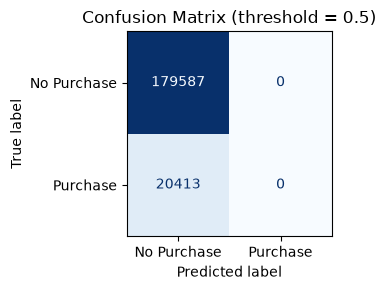

In [20]:
# ── Predicted probabilities from Model 2 ──────────────────────────────────────
y_pred_prob = model2.predict(X2)

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y, y_pred_prob)
print(f"ROC-AUC (Adjusted Model): {auc:.4f}")
print(f"Predicted probability range: {y_pred_prob.min():.3f} to {y_pred_prob.max():.3f}")
print(f"Observed purchase rate:      {y.mean():.3f}")

# ── Confusion matrix at 0.5 threshold ─────────────────────────────────────────
y_pred_class = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_class)

fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

### Evaluation notes

- **ROC-AUC** measures how well the model separates purchasers from non-purchasers across all possible classification thresholds. An AUC of 0.5 would mean no better than random; AUC of 1.0 would be perfect separation.
- **Classification performance is not the main objective of this notebook.** This model is fitted to understand the *association* between covariates and purchase probability — not to build a production classifier.
- A low or moderate AUC does not undermine the finding about Variant B. Even a model with limited predictive power can produce precise, statistically significant coefficient estimates.
- The confusion matrix at a 0.5 threshold reflects the class imbalance (~10% purchase rate). In practice, the threshold would be chosen based on business cost trade-offs, but that optimisation is outside the scope of this notebook.
- The A/B test conclusion — whether Variant B *caused* a change in conversion — rests on the randomisation and the z-test, not on the AUC.

## 8. Key Findings

1. **Variant B remains positively associated with purchase after adjustment.** The Variant B odds ratio in Model 2 (adjusted) is consistent in direction and magnitude with Model 1 (variant only), indicating that the treatment relationship is not explained away by device, country, traffic source, or new user status.

2. **The direction agrees with the A/B test.** Both the z-test (Notebook 03) and both logistic regression models point in the same direction: Variant B is associated with higher purchase probability. This consistency provides additional confidence in the finding.

3. **The estimated effect does not change materially after adjustment.** The small change in the Variant B odds ratio between Model 1 and Model 2 is expected in a properly randomised experiment where covariates are balanced across variants. It suggests no meaningful confounding by the observed pre-treatment variables.

4. **Other predictors reveal interesting patterns.** The adjusted model shows that device type, country, traffic source, and new/returning user status are all associated with purchase probability to varying degrees. For example, email traffic and returning users tend to show higher conversion associations — patterns worth noting for targeting or personalisation decisions, though these are observational associations, not causal claims.

5. **The A/B test remains the primary experiment analysis.** Because users were randomly assigned, the z-test provides the cleanest evidence that Variant B *caused* the observed conversion difference. Logistic regression adds a complementary regression-based perspective and quantifies the covariate-adjusted relationship, but does not alter the causal conclusion.

6. **Post-treatment variables were excluded.** Variables such as `checkout_started`, `payment_failed`, `refund`, and `revenue` occur after treatment assignment and were deliberately excluded from all predictive models to avoid post-treatment bias.

## 9. Limitations

- **Association, not causation (for covariates).** Logistic regression models the statistical association between predictors and purchase probability. For the treatment variable (`variant`), causal interpretation is supported by the randomised experiment design. For other predictors (device, country, traffic source, new user), the relationships should be interpreted as associations only.

- **The randomised A/B test remains the primary causal basis.** The logistic regression does not replace or strengthen the causal claim beyond what the randomisation already provides.

- **Observational covariates are not exhaustively controlled.** The model includes only available variables. Unmeasured factors (e.g. user intent, prior purchase history beyond the experiment window) could still confound covariate relationships.

- **The dataset is synthetic.** Results are illustrative for the purposes of this portfolio case study.

- **No long-term business impact.** Logistic regression on experiment data does not establish what conversion rates would look like after a full rollout, user adaptation, or seasonal effects.

- **Post-treatment variables excluded by design.** `sessions` and `page_load_time_ms` were excluded because their measurement window is not clearly pre-treatment based on the data dictionary, and including them could introduce bias.

## 10. Final Conclusion

This notebook completes the analytical picture of the E-Commerce Checkout A/B Testing project alongside three complementary analyses:

| Analysis | Notebook | Question answered |
|---|---|---|
| A/B Test (z-test) | 03 | *Did Variant B change conversion?* → **Yes** (p ≈ 5.93e-13, 95% CI: +0.71 pp to +1.24 pp) |
| Business Analysis | 04 | *Was the difference practically meaningful?* → **Yes** (≈ +10% relative lift, positive projected revenue impact) |
| **Logistic Regression** | **05** | *Does the Variant B relationship remain after adjusting for basic user characteristics?* → **Yes** (OR consistent across unadjusted and adjusted models) |
